In [1]:
import contextlib
import io
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from rdkit.Chem.Draw import IPythonConsole
from rdkit import Chem,RDLogger

ROOT = Path.cwd().resolve()
REPO_ROOT = ROOT.parent if ROOT.name == "notebook" else ROOT
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from catemb import CatEmb
from catemb.recommend import random_init, recommend_by_random, recommend_by_dist, recommend_by_model
from catemb.utils import link_lig_to_metal
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
RDLogger.DisableLog('rdApp.*')
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 400, 400

PLOT_COLORS = {"random": "coral", "model": "green", "similarity": "deepskyblue"}


def quiet_call(fn, *args, **kwargs):
    with contextlib.redirect_stdout(io.StringIO()):
        return fn(*args, **kwargs)


def plot_recommendation_curves(exp_times, curves, xlabel, ylabel, output_path, xticks):
    fig, ax = plt.subplots(figsize=(5.2, 5), dpi=150)
    for name, values in curves:
        ax.plot(
            exp_times,
            values,
            color=PLOT_COLORS[name],
            lw=2,
            marker="o",
            ms=4.5,
            markeredgecolor="white",
            markeredgewidth=0.7,
            label=name,
        )
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(x) for x in xticks], fontsize=13)
    ax.tick_params(axis="y", labelsize=13)
    ax.legend(frameon=False, fontsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.18, linewidth=0.8)
    plt.tight_layout()
    output_dir = os.path.dirname(str(output_path))
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


/opt/conda/envs/catemb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Substrate-general optimal catalyst/ligand recommendation

## C–H arylation dataset

In [2]:
rxn_data = pd.read_csv("../dataset/rxn_data/aryl-scope-ligand.csv")
lig_smi_lst, rct1_smi_lst, rct2_smi_lst, pdt_smi_lst = rxn_data['ligand_smiles'].to_list(),rxn_data['electrophile_smiles'].to_list(),rxn_data['nucleophile_smiles'].to_list(),rxn_data['product_smiles'].to_list()
label = rxn_data['yield'].to_numpy()

In [3]:
lig_smi_yield_map = {}
for lig_smi, yield_ in zip(lig_smi_lst,label):
    if not lig_smi in lig_smi_yield_map:
        lig_smi_yield_map[lig_smi] = [yield_]
    else:
        lig_smi_yield_map[lig_smi].append(yield_)
lig_smi_ave_yield_lst = sorted([[smi,np.mean(lig_smi_yield_map[smi])] for smi in lig_smi_yield_map],key=lambda x: x[1])
tgt_lig_smi = lig_smi_ave_yield_lst[-1][0]

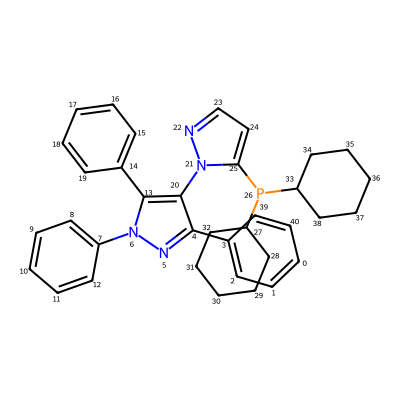

In [4]:
Chem.MolFromSmiles(tgt_lig_smi)

In [5]:
batch_size = 2
leave_best_topk = 0
recommend_time = 4
test_time = 100

### Random recommendation

In [6]:
all_cur_best_lst = []
all_match_best_lig_lst = []
for i in range(test_time):

    cur_best_lst = []
    exp_times = []
    match_best_lig_lst = []
    cur_score,cur_cat,pool_cat = quiet_call(random_init, lig_smi_ave_yield_lst,leave_best_topk=leave_best_topk,batch_size=batch_size,rand_seed=i)
    cur_best_lst.append(max(cur_score))
    exp_times.append(len(cur_score))
    if tgt_lig_smi in [item[0] for item in cur_cat]:
        match_best_lig_lst.append(1)
    else:
        match_best_lig_lst.append(0)

    for _ in range(recommend_time):
        cur_score,cur_cat,pool_cat = quiet_call(recommend_by_random, cur_score,cur_cat,pool_cat,batch_size=batch_size)
        cur_best_lst.append(max(cur_score))
        exp_times.append(len(cur_score))
        if tgt_lig_smi in [item[0] for item in cur_cat]:
            match_best_lig_lst.append(1)
        else:
            match_best_lig_lst.append(0)

    all_cur_best_lst.append(cur_best_lst)
    all_match_best_lig_lst.append(match_best_lig_lst)
rand_ave_cur_best_arr = np.array(all_cur_best_lst).mean(0)
rand_ave_cur_match_best_arr = np.array(all_match_best_lig_lst).mean(0)

### Similarity-based recommendation

In [7]:
catemb_calc = CatEmb(device='cpu')

In [8]:
all_cur_best_lst = []
all_match_best_lig_lst = []
for i in range(test_time):

    cur_best_lst = []
    exp_times = []
    match_best_lig_lst = []
    cur_score,cur_cat,pool_cat = quiet_call(random_init, lig_smi_ave_yield_lst,leave_best_topk=leave_best_topk,batch_size=batch_size,rand_seed=i)
    cur_best_lst.append(max(cur_score))
    exp_times.append(len(cur_score))
    
    if tgt_lig_smi in [item[0] for item in cur_cat]:
        match_best_lig_lst.append(1)
    else:
        match_best_lig_lst.append(0)
    
    for _ in range(recommend_time):
        cur_score,cur_cat,pool_cat = quiet_call(recommend_by_dist, catemb_calc,cur_score,cur_cat,pool_cat,batch_size=batch_size,best_n=1)
        cur_best_lst.append(max(cur_score))
        exp_times.append(len(cur_score))
        
        if tgt_lig_smi in [item[0] for item in cur_cat]:
            match_best_lig_lst.append(1)
        else:
            match_best_lig_lst.append(0)
    all_cur_best_lst.append(cur_best_lst)
    all_match_best_lig_lst.append(match_best_lig_lst)
dist_ave_cur_best_arr = np.array(all_cur_best_lst).mean(0)
dist_ave_cur_match_best_arr = np.array(all_match_best_lig_lst).mean(0)


### Model-based recommendation (catalyst-OOS-selected rxnfp + CatEmb QSPR)

Use the best catalyst-OOS configurations selected in `oos_qsrp.ipynb`: Aryl scope uses CatEmb dim 16 + SVR; Thiol addition uses CatEmb dim 512 + Ridge.


In [9]:
ARYL_CAT_OOS_CATEMB_DIM = 16
ARYL_CAT_OOS_MODEL_TYPE = "SVR"
aryl_model_path = '/inspire/hdd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/CatEmb/save_model/260423-1014h_equif_plat_lr1e-4_decay_step5_temp0.1_EBM_dot_prod_xtbopt62755_equif_first_dim16_cl_kl_e_111_ln'
aryl_model_catemb_calc = CatEmb(model_path=aryl_model_path, device='cpu')
aryl_model = make_pipeline(StandardScaler(), SVR(C=10.0, epsilon=0.1))


In [10]:
aryl_rxnfp_wo_lig_map = np.load("./gen_desc/aryl_scope_rxn_smi_wo_lig_rxnfp_map.npy", allow_pickle=True).item()
rct12_pdt_pair_set = list(set([(rct1_smi_lst[i], rct2_smi_lst[i], pdt_smi_lst[i]) for i in range(len(rct1_smi_lst))]))
rxn_smi_fp_map = aryl_rxnfp_wo_lig_map
rxn_smi_label_map = {
    f"{rct1}.{rct2}>{lig}>{pdt}": label[i]
    for i, (rct1, rct2, lig, pdt) in enumerate(zip(rct1_smi_lst, rct2_smi_lst, lig_smi_lst, pdt_smi_lst))
}
lig_cat_df = pd.read_csv("../dataset/rxn_data/ligand_catalyst_map_of_aryl.csv")
lig_cat_map = {lig: cat for lig, cat in zip(lig_cat_df["Ligand"], lig_cat_df["Catalyst"])}
lig_smi_to_pd_cat_smi_lst_map = {lig: [lig_cat_map[lig]] for lig in set(lig_smi_lst)}
aryl_desc_smi_lst = sorted(set(lig_smi_lst + [lig_cat_map[lig] for lig in lig_smi_lst]))
aryl_catemb_desc_arr = aryl_model_catemb_calc.gen_desc(aryl_desc_smi_lst, batch_size=64)
aryl_cat_smi_desc_map = {smi: np.asarray(desc) for smi, desc in zip(aryl_desc_smi_lst, aryl_catemb_desc_arr)}

all_cur_best_lst = []
all_match_best_lig_lst = []
for i in range(test_time):

    cur_best_lst = []
    exp_times = []
    match_best_lig_lst = []
    cur_score,cur_cat,pool_cat = quiet_call(random_init, lig_smi_ave_yield_lst,leave_best_topk=leave_best_topk,batch_size=batch_size,rand_seed=i)
    cur_best_lst.append(max(cur_score))
    exp_times.append(len(cur_score))
    
    if tgt_lig_smi in [item[0] for item in cur_cat]:
        match_best_lig_lst.append(1)
    else:
        match_best_lig_lst.append(0)
    
    for _ in range(recommend_time):
        cur_score,cur_cat,pool_cat = quiet_call(recommend_by_model, 
            cur_score,
            cur_cat,
            pool_cat,
            rct12_pdt_pair_set,
            rxn_smi_fp_map,
            rxn_smi_label_map,
            aryl_model,
            batch_size=batch_size,
            cat_smi_desc_map=aryl_cat_smi_desc_map,
            cat_smi_to_extra_smi_lst_map=lig_smi_to_pd_cat_smi_lst_map,
        )
        cur_best_lst.append(max(cur_score))
        exp_times.append(len(cur_score))
        
        if tgt_lig_smi in [item[0] for item in cur_cat]:
            match_best_lig_lst.append(1)
        else:
            match_best_lig_lst.append(0)
    all_cur_best_lst.append(cur_best_lst)
    all_match_best_lig_lst.append(match_best_lig_lst)
model_ave_cur_best_arr = np.array(all_cur_best_lst).mean(0)
model_ave_cur_match_best_arr = np.array(all_match_best_lig_lst).mean(0)


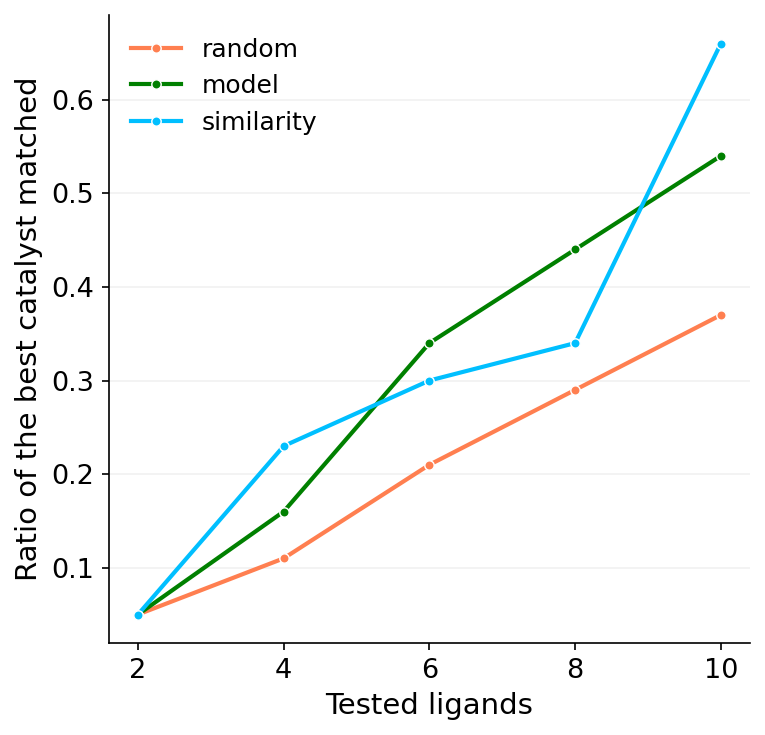

In [11]:
plot_recommendation_curves(
    exp_times,
    [("random", rand_ave_cur_match_best_arr), ("model", model_ave_cur_match_best_arr), ("similarity", dist_ave_cur_match_best_arr)],
    "Tested ligands",
    "Ratio of the best catalyst matched",
    "./recommend_results/aryl_scope_model_match_best_oos_svr_dim16.png",
    [2, 4, 6, 8, 10],
)

## Asymmetric thiol addition dataset

In [10]:
rxn_data = pd.read_csv("../dataset/rxn_data/NS_acetal_dataset_with_pdt.csv")
rxn_data

,Unnamed: 0,Imine,Thiol,Catalyst,ΔΔG,Product
0,0,O=C(/N=C/c1ccccc1)c1ccccc1,Sc1ccccc1,O=P1(O)Oc2c(-c3ccccc3)cc3ccccc3c2-c2c(c(-c3ccc...,1.179891,O=C(NC(Sc1ccccc1)c1ccccc1)c1ccccc1
1,1,O=C(/N=C/c1ccccc1)c1ccccc1,CCS,O=P1(O)Oc2c(-c3ccccc3)cc3ccccc3c2-c2c(c(-c3ccc...,0.501759,CCSC(NC(=O)c1ccccc1)c1ccccc1
2,2,O=C(/N=C/c1ccccc1)c1ccccc1,SC1CCCCC1,O=P1(O)Oc2c(-c3ccccc3)cc3ccccc3c2-c2c(c(-c3ccc...,0.650584,O=C(NC(SC1CCCCC1)c1ccccc1)c1ccccc1
3,3,O=C(/N=C/c1ccccc1)c1ccccc1,COc1ccc(S)cc1,O=P1(O)Oc2c(-c3ccccc3)cc3ccccc3c2-c2c(c(-c3ccc...,1.238109,COc1ccc(SC(NC(=O)c2ccccc2)c2ccccc2)cc1
4,4,O=C(/N=C/c1ccc(C(F)(F)F)cc1)c1ccccc1,Sc1ccccc1,O=P1(O)Oc2c(-c3ccccc3)cc3ccccc3c2-c2c(c(-c3ccc...,1.179891,O=C(NC(Sc1ccccc1)c1ccc(C(F)(F)F)cc1)c1ccccc1
...,...,...,...,...,...,...
1070,1070,O=C(/N=C/c1ccccc1)c1ccccc1,Sc1ccccc1,O=P1(O)Oc2c(-c3cc(C(F)(F)F)cc(C(F)(F)F)c3)cc3c...,1.531803,O=C(NC(Sc1ccccc1)c1ccccc1)c1ccccc1
1071,1071,O=C(/N=C/c1ccccc1)c1ccccc1,Cc1ccccc1S,O=P1(O)Oc2c(-c3cc(C(F)(F)F)cc(C(F)(F)F)c3)cc3c...,1.531803,Cc1ccccc1SC(NC(=O)c1ccccc1)c1ccccc1
1072,1072,O=C(/N=C/c1ccc(C(F)(F)F)cc1)c1ccccc1,Cc1ccccc1S,O=P1(O)Oc2c(-c3cc(C(F)(F)F)cc(C(F)(F)F)c3)cc3c...,1.370104,Cc1ccccc1SC(NC(=O)c1ccccc1)c1ccc(C(F)(F)F)cc1
1073,1073,O=C(/N=C/c1cccc2ccccc12)c1ccccc1,Sc1ccccc1,O=P1(O)Oc2c(-c3cc(C(F)(F)F)cc(C(F)(F)F)c3)cc3c...,1.301167,O=C(NC(Sc1ccccc1)c1cccc2ccccc12)c1ccccc1


In [11]:
imine_lst = rxn_data['Imine'].to_list()
thiol_lst = rxn_data['Thiol'].to_list()
cat_lst = rxn_data['Catalyst'].to_list()
pdt_lst = rxn_data['Product'].to_list()
label = rxn_data['ΔΔG'].to_numpy()

cat_label_map = {}
for cat,l in zip(cat_lst,label):
    if cat not in cat_label_map:
        cat_label_map[cat] = []
    cat_label_map[cat].append(l)
cat_label_lst = sorted([[cat,np.mean(l)] for cat,l in cat_label_map.items()],key=lambda x:x[1])
tgt_cat_smi = cat_label_lst[-1][0]

In [12]:
batch_size = 2
leave_best_topk = 0
recommend_time = 9
test_time = 100

### Random recommendation

In [13]:

all_cur_best_lst = []
all_match_best_lig_lst = []
cur_max_score_lst = []
for i in range(test_time):

    cur_best_lst = []
    exp_times = []
    match_best_lig_lst = []
    cur_score,cur_cat,pool_cat = quiet_call(random_init, cat_label_lst,leave_best_topk=leave_best_topk,batch_size=batch_size,rand_seed=i)
    if len(cur_score) > 0:
        max_score = max(cur_score)
    else:
        max_score = 0
    cur_best_lst.append(max_score)
    exp_times.append(len(cur_score))
    if tgt_cat_smi in [item[0] for item in cur_cat]:
        match_best_lig_lst.append(1)
    else:
        match_best_lig_lst.append(0)

    for _ in range(recommend_time):
        cur_score,cur_cat,pool_cat = quiet_call(recommend_by_random, cur_score,cur_cat,pool_cat,batch_size=batch_size)
        cur_best_lst.append(max(cur_score))
        exp_times.append(len(cur_score))
        if tgt_cat_smi in [item[0] for item in cur_cat]:
            match_best_lig_lst.append(1)
        else:
            match_best_lig_lst.append(0)

    all_cur_best_lst.append(cur_best_lst)
    all_match_best_lig_lst.append(match_best_lig_lst)
rand_ave_cur_best_arr = np.array(all_cur_best_lst).mean(0)
rand_ave_cur_match_best_arr = np.array(all_match_best_lig_lst).mean(0)

### Similarity-based recommendation

In [14]:
catemb_calc = CatEmb(device='cpu')

In [15]:
all_cur_best_lst = []
all_match_best_lig_lst = []
for i in range(test_time):

    cur_best_lst = []
    exp_times = []
    match_best_lig_lst = []
    cur_score,cur_cat,pool_cat = quiet_call(random_init, cat_label_lst,leave_best_topk=leave_best_topk,batch_size=batch_size,rand_seed=i)
    if len(cur_score) == 0:
        max_score = 0
    else:
        max_score = max(cur_score)
    cur_best_lst.append(max_score)
    exp_times.append(len(cur_score))
    
    if tgt_cat_smi in [item[0] for item in cur_cat]:
        match_best_lig_lst.append(1)
    else:
        match_best_lig_lst.append(0)
    
    for _ in range(recommend_time):
        cur_score,cur_cat,pool_cat = quiet_call(recommend_by_dist, catemb_calc,cur_score,cur_cat,pool_cat,batch_size=batch_size,best_n=1)
        cur_best_lst.append(max(cur_score))
        exp_times.append(len(cur_score))
        
        if tgt_cat_smi in [item[0] for item in cur_cat]:
            match_best_lig_lst.append(1)
        else:
            match_best_lig_lst.append(0)
    all_cur_best_lst.append(cur_best_lst)
    all_match_best_lig_lst.append(match_best_lig_lst)
dist_ave_cur_best_arr = np.array(all_cur_best_lst).mean(0)
dist_ave_cur_match_best_arr = np.array(all_match_best_lig_lst).mean(0)

### Model-based recommendation (catalyst-OOS-selected rxnfp + CatEmb QSPR)

Use the best catalyst-OOS configurations selected in `oos_qsrp.ipynb`: Aryl scope uses CatEmb dim 16 + SVR; Thiol addition uses CatEmb dim 512 + Ridge.


In [18]:
THIOL_CAT_OOS_CATEMB_DIM = 512
THIOL_CAT_OOS_MODEL_TYPE = "Ridge"
thiol_model_path = '/inspire/hdd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/CatEmb/save_model/260427-0648h_equif_plat_lr1e-4_decay_step5_temp0.1_EBM_dot_prod_xtbopt62755_equif_first_dim512_cl_kl_e_111_ln'
thiol_model_catemb_calc = CatEmb(model_path=thiol_model_path, device='cpu')
thiol_model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))


In [19]:
rxn_smi_fp_map = np.load("./gen_desc/thiol_add_rxn_smi_wo_cat_rxnfp_map.npy", allow_pickle=True).item()
rct12_pdt_pair_set = list(set([(imine_lst[i],thiol_lst[i],pdt_lst[i]) for i in range(len(imine_lst))]))
rxn_smi_label_map = {
    f"{imine}.{thiol}>{cat}>{pdt}": label[i]
    for i, (imine, thiol, cat, pdt) in enumerate(zip(imine_lst, thiol_lst, cat_lst, pdt_lst))
}
thiol_desc_smi_lst = sorted(set(cat_lst))
thiol_catemb_desc_arr = thiol_model_catemb_calc.gen_desc(thiol_desc_smi_lst, batch_size=64)
thiol_cat_smi_desc_map = {smi: np.asarray(desc) for smi, desc in zip(thiol_desc_smi_lst, thiol_catemb_desc_arr)}

all_cur_best_lst = []
all_match_best_lig_lst = []
for i in range(test_time):

    cur_best_lst = []
    exp_times = []
    match_best_lig_lst = []
    cur_score,cur_cat,pool_cat = quiet_call(random_init, cat_label_lst,leave_best_topk=leave_best_topk,batch_size=batch_size,rand_seed=i)
    if len(cur_score) == 0:
        max_score = 0
    else:
        max_score = max(cur_score)
    cur_best_lst.append(max_score)
    exp_times.append(len(cur_score))
    
    if tgt_cat_smi in [item[0] for item in cur_cat]:
        match_best_lig_lst.append(1)
    else:
        match_best_lig_lst.append(0)
    
    for _ in range(recommend_time):
        cur_score,cur_cat,pool_cat = quiet_call(recommend_by_model, 
            cur_score,
            cur_cat,
            pool_cat,
            rct12_pdt_pair_set,
            rxn_smi_fp_map,
            rxn_smi_label_map,
            thiol_model,
            batch_size=batch_size,
            cat_smi_desc_map=thiol_cat_smi_desc_map,
        )
        cur_best_lst.append(max(cur_score))
        exp_times.append(len(cur_score))
        
        if tgt_cat_smi in [item[0] for item in cur_cat]:
            match_best_lig_lst.append(1)
        else:
            match_best_lig_lst.append(0)
    all_cur_best_lst.append(cur_best_lst)
    all_match_best_lig_lst.append(match_best_lig_lst)

model_ave_cur_best_arr = np.array(all_cur_best_lst).mean(0)
model_ave_cur_match_best_arr = np.array(all_match_best_lig_lst).mean(0)


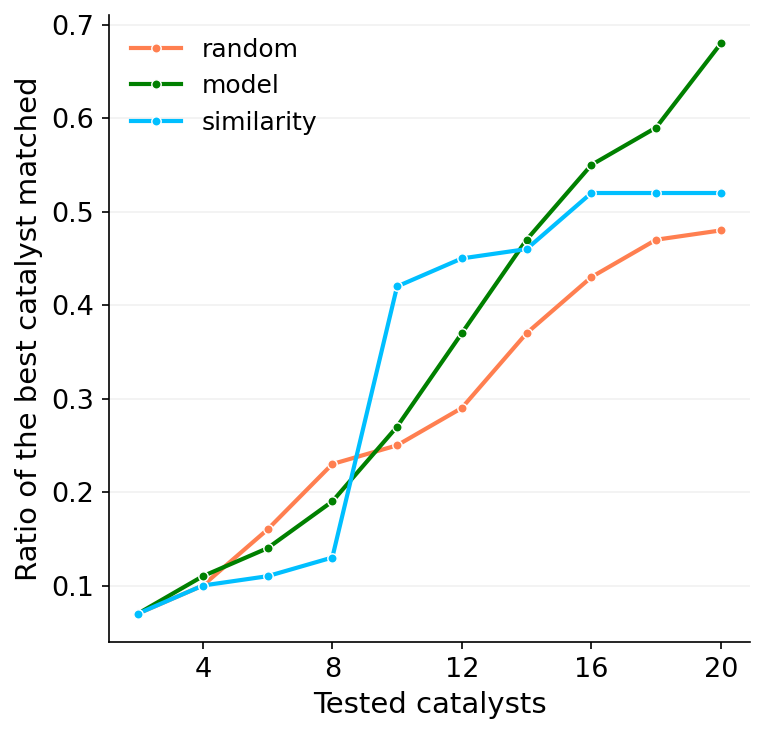

In [20]:
plot_recommendation_curves(
    exp_times,
    [("random", rand_ave_cur_match_best_arr), ("model", model_ave_cur_match_best_arr), ("similarity", dist_ave_cur_match_best_arr)],
    "Tested catalysts",
    "Ratio of the best catalyst matched",
    "./recommend_results/thiol_add_model_match_best_lig_oos_ridge_dim512.png",
    [4, 8, 12, 16, 20],
)

# High-performance reaction-combination recommendation

In [16]:
rxn_recommend_result_dir = "./recommend_results/activity_selectivity_optimization"
os.makedirs(rxn_recommend_result_dir, exist_ok=True)

ARYL_YIELD_THRESHOLD = 90.0
THIOL_TEMPERATURE_K = 298.15
THIOL_EE_THRESHOLD = 0.90
ARYL_REACTION_BATCH_SIZE = 10
ARYL_REACTION_RECOMMEND_TIME = 4
THIOL_REACTION_BATCH_SIZE = 10
THIOL_REACTION_RECOMMEND_TIME = 4


def ddG2ee(ddG,T):
    ddG = np.asarray(ddG)*1000*4.18
    ee = (1-np.exp(ddG/(8.314*T)))/(1+np.exp(ddG/(8.314*T)))
    return np.abs(ee)


def average_found_ratio_curve(target_mask, score_arr, batch_size, recommend_time, strategy_fn):
    curves = []
    exp_times = None
    n = len(target_mask)
    n_target = int(np.sum(target_mask))
    for seed in range(test_time):
        rng = np.random.default_rng(seed)
        order = rng.permutation(n)
        cur_idx = order[:batch_size].tolist()
        pool_idx = order[batch_size:].tolist()
        found_ratio = [float(np.sum(target_mask[cur_idx]) / n_target)]
        cur_exp_times = [len(cur_idx)]
        for _ in range(recommend_time):
            take = min(batch_size, len(pool_idx))
            new_idx = strategy_fn(cur_idx, pool_idx, take, rng)
            cur_idx.extend(new_idx)
            new_idx_set = set(new_idx)
            pool_idx = [idx for idx in pool_idx if idx not in new_idx_set]
            found_ratio.append(float(np.sum(target_mask[cur_idx]) / n_target))
            cur_exp_times.append(len(cur_idx))
        curves.append(found_ratio)
        exp_times = cur_exp_times
    return np.asarray(exp_times), np.asarray(curves).mean(axis=0)


def reaction_random_strategy(cur_idx, pool_idx, take, rng):
    return [pool_idx[idx] for idx in rng.choice(len(pool_idx), take, replace=False)]


def reaction_similarity_strategy(desc, score_arr, best_n=1):
    desc = StandardScaler().fit_transform(desc)
    def _strategy(cur_idx, pool_idx, take, rng):
        best_idx = np.asarray(cur_idx)[np.argsort(score_arr[cur_idx])[-best_n:]]
        pool_desc = desc[pool_idx]
        dist = np.sum([np.linalg.norm(pool_desc - desc[idx], axis=1) for idx in best_idx], axis=0)
        return [pool_idx[idx] for idx in np.argsort(dist)[:take]]
    return _strategy


def make_reaction_model(model_type):
    if model_type == "ExtraTrees":
        return ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    if model_type == "Ridge":
        return make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    if model_type == "SVR":
        return make_pipeline(StandardScaler(), SVR(C=10.0, epsilon=0.1))
    raise ValueError(model_type)


def reaction_model_strategy(feature_arr, score_arr, model_type):
    def _strategy(cur_idx, pool_idx, take, rng):
        cur_idx_arr = np.asarray(cur_idx)
        pool_idx_arr = np.asarray(pool_idx)
        model = make_reaction_model(model_type)
        model.fit(feature_arr[cur_idx_arr], score_arr[cur_idx_arr])
        pred = model.predict(feature_arr[pool_idx_arr])
        return [pool_idx[idx] for idx in np.argsort(-pred)[:take]]
    return _strategy


## C–H arylation dataset: yield > 90% reaction recovery

,tested_reactions,random_found_ratio,model_found_ratio,similarity_found_ratio
0,10,0.006418,0.006418,0.006418
1,20,0.013134,0.012687,0.025821
2,30,0.020746,0.022687,0.054179
3,40,0.027463,0.038657,0.077910
4,50,0.034030,0.056866,0.093284


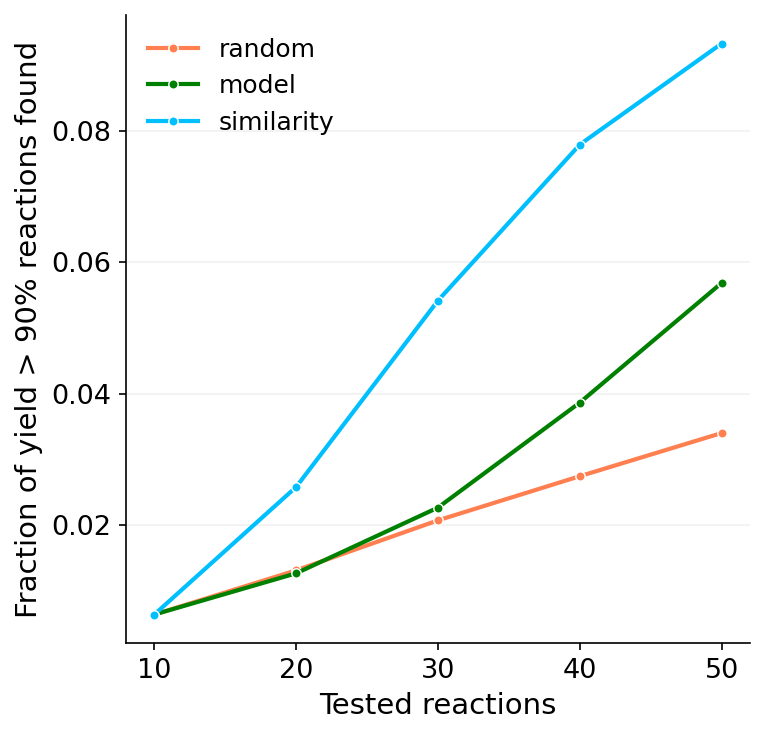

In [17]:
aryl_reaction_data = pd.read_csv("../dataset/rxn_data/aryl-scope-ligand.csv")
aryl_lig_smi_lst = aryl_reaction_data['ligand_smiles'].to_list()
aryl_rct1_smi_lst = aryl_reaction_data['electrophile_smiles'].to_list()
aryl_rct2_smi_lst = aryl_reaction_data['nucleophile_smiles'].to_list()
aryl_pdt_smi_lst = aryl_reaction_data['product_smiles'].to_list()
aryl_y = aryl_reaction_data['yield'].to_numpy(float)

lig_cat_df = pd.read_csv("../dataset/rxn_data/ligand_catalyst_map_of_aryl.csv")
lig_cat_map = {lig: cat for lig, cat in zip(lig_cat_df["Ligand"], lig_cat_df["Catalyst"])}
aryl_cat_smi_lst = [lig_cat_map[lig] for lig in aryl_lig_smi_lst]
aryl_rxnfp_map = np.load("./gen_desc/aryl_scope_rxn_smi_wo_lig_rxnfp_map.npy", allow_pickle=True).item()
aryl_rxn_smi_wo_lig_lst = [
    f"{rct1}.{rct2}>>{pdt}"
    for rct1, rct2, pdt in zip(aryl_rct1_smi_lst, aryl_rct2_smi_lst, aryl_pdt_smi_lst)
]
aryl_rxnfp_arr = np.array([aryl_rxnfp_map[rxn_smi] for rxn_smi in aryl_rxn_smi_wo_lig_lst])

aryl_reaction_catemb_calc = CatEmb(model_path=aryl_model_path, device='cpu')
aryl_desc_smi_lst = sorted(set(aryl_lig_smi_lst + aryl_cat_smi_lst))
aryl_desc_arr = aryl_reaction_catemb_calc.gen_desc(aryl_desc_smi_lst, batch_size=64)
aryl_desc_map = {smi: np.asarray(desc) for smi, desc in zip(aryl_desc_smi_lst, aryl_desc_arr)}
aryl_lig_desc = np.array([aryl_desc_map[smi] for smi in aryl_lig_smi_lst])
aryl_cat_desc = np.array([aryl_desc_map[smi] for smi in aryl_cat_smi_lst])
aryl_reaction_feature_arr = np.concatenate([aryl_rxnfp_arr, aryl_lig_desc, aryl_cat_desc], axis=1)
aryl_target = aryl_y > ARYL_YIELD_THRESHOLD

aryl_reaction_exp_times, aryl_reaction_random_ratio = average_found_ratio_curve(
    aryl_target,
    aryl_y,
    ARYL_REACTION_BATCH_SIZE,
    ARYL_REACTION_RECOMMEND_TIME,
    reaction_random_strategy,
)
_, aryl_reaction_similarity_ratio = average_found_ratio_curve(
    aryl_target,
    aryl_y,
    ARYL_REACTION_BATCH_SIZE,
    ARYL_REACTION_RECOMMEND_TIME,
    reaction_similarity_strategy(aryl_reaction_feature_arr, aryl_y),
)
_, aryl_reaction_model_ratio = average_found_ratio_curve(
    aryl_target,
    aryl_y,
    ARYL_REACTION_BATCH_SIZE,
    ARYL_REACTION_RECOMMEND_TIME,
    reaction_model_strategy(aryl_reaction_feature_arr, aryl_y, "SVR"),
)

aryl_reaction_curve_df = pd.DataFrame({
    "tested_reactions": aryl_reaction_exp_times,
    "random_found_ratio": aryl_reaction_random_ratio,
    "model_found_ratio": aryl_reaction_model_ratio,
    "similarity_found_ratio": aryl_reaction_similarity_ratio,
})
display(aryl_reaction_curve_df)
aryl_reaction_curve_df.to_csv(f"{rxn_recommend_result_dir}/aryl_scope_reaction_yield90_found_ratio_curves.csv", index=False)
plot_recommendation_curves(
    aryl_reaction_exp_times,
    [("random", aryl_reaction_random_ratio), ("model", aryl_reaction_model_ratio), ("similarity", aryl_reaction_similarity_ratio)],
    "Tested reactions",
    "Fraction of yield > 90% reactions found",
    f"{rxn_recommend_result_dir}/aryl_scope_reaction_yield90_found_ratio.png",
    aryl_reaction_exp_times,
)

## Asymmetric thiol addition dataset: ee > 90% reaction recovery

,tested_reactions,random_found_ratio,model_found_ratio,similarity_found_ratio
0,10,0.009902,0.009902,0.009902
1,20,0.017941,0.038137,0.052255
2,30,0.027451,0.069510,0.090294
3,40,0.035588,0.106765,0.118039
4,50,0.044118,0.142353,0.145588


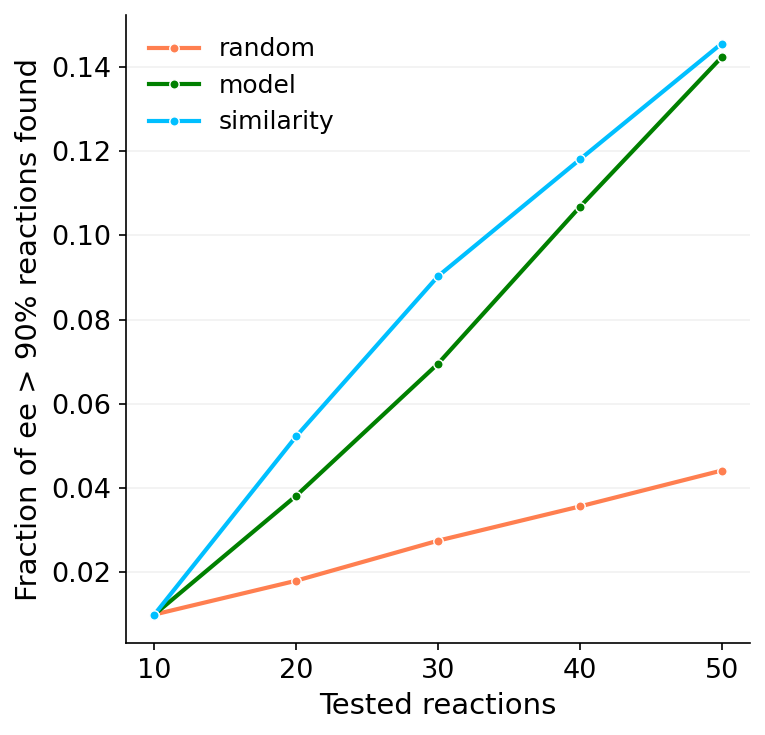

In [23]:
thiol_reaction_data = pd.read_csv("../dataset/rxn_data/NS_acetal_dataset_with_pdt.csv")
thiol_imine_lst = thiol_reaction_data['Imine'].to_list()
thiol_thiol_lst = thiol_reaction_data['Thiol'].to_list()
thiol_cat_smi_lst = thiol_reaction_data['Catalyst'].to_list()
thiol_pdt_smi_lst = thiol_reaction_data['Product'].to_list()
thiol_y = thiol_reaction_data['ΔΔG'].to_numpy(float)
thiol_ee = ddG2ee(thiol_y, THIOL_TEMPERATURE_K)
thiol_target = thiol_ee > THIOL_EE_THRESHOLD

thiol_rxnfp_map = np.load("./gen_desc/thiol_add_rxn_smi_wo_cat_rxnfp_map.npy", allow_pickle=True).item()
thiol_rxn_smi_wo_cat_lst = [
    f"{imine}.{thiol}>>{pdt}"
    for imine, thiol, pdt in zip(thiol_imine_lst, thiol_thiol_lst, thiol_pdt_smi_lst)
]
thiol_rxnfp_arr = np.array([thiol_rxnfp_map[rxn_smi] for rxn_smi in thiol_rxn_smi_wo_cat_lst])

thiol_reaction_catemb_calc = CatEmb(model_path=thiol_model_path, device='cpu')
thiol_desc_smi_lst = sorted(set(thiol_cat_smi_lst))
thiol_desc_arr = thiol_reaction_catemb_calc.gen_desc(thiol_desc_smi_lst, batch_size=64)
thiol_desc_map = {smi: np.asarray(desc) for smi, desc in zip(thiol_desc_smi_lst, thiol_desc_arr)}
thiol_cat_desc = np.array([thiol_desc_map[smi] for smi in thiol_cat_smi_lst])
thiol_reaction_feature_arr = np.concatenate([thiol_rxnfp_arr, thiol_cat_desc], axis=1)

thiol_reaction_exp_times, thiol_reaction_random_ratio = average_found_ratio_curve(
    thiol_target,
    thiol_y,
    THIOL_REACTION_BATCH_SIZE,
    THIOL_REACTION_RECOMMEND_TIME,
    reaction_random_strategy,
)
_, thiol_reaction_similarity_ratio = average_found_ratio_curve(
    thiol_target,
    thiol_y,
    THIOL_REACTION_BATCH_SIZE,
    THIOL_REACTION_RECOMMEND_TIME,
    reaction_similarity_strategy(thiol_reaction_feature_arr, thiol_y),
)
_, thiol_reaction_model_ratio = average_found_ratio_curve(
    thiol_target,
    thiol_y,
    THIOL_REACTION_BATCH_SIZE,
    THIOL_REACTION_RECOMMEND_TIME,
    reaction_model_strategy(thiol_reaction_feature_arr, thiol_y, "Ridge"),
)

thiol_reaction_curve_df = pd.DataFrame({
    "tested_reactions": thiol_reaction_exp_times,
    "random_found_ratio": thiol_reaction_random_ratio,
    "model_found_ratio": thiol_reaction_model_ratio,
    "similarity_found_ratio": thiol_reaction_similarity_ratio,
})
display(thiol_reaction_curve_df)
thiol_reaction_curve_df.to_csv(f"{rxn_recommend_result_dir}/thiol_addition_reaction_ee90_found_ratio_curves.csv", index=False)
plot_recommendation_curves(
    thiol_reaction_exp_times,
    [("random", thiol_reaction_random_ratio), ("model", thiol_reaction_model_ratio), ("similarity", thiol_reaction_similarity_ratio)],
    "Tested reactions",
    "Fraction of ee > 90% reactions found",
    f"{rxn_recommend_result_dir}/thiol_addition_reaction_ee90_found_ratio.png",
    thiol_reaction_exp_times,
)

## Suzuki–Miyaura cross-coupling

In [24]:

rxn_data = pd.read_csv('../dataset/rxn_data/com_data_with_cplex_smi.csv')
lig_lib = np.load("../dataset/rxn_data/smi_sascore_map.npy",allow_pickle=True).item()
sel_lig_lib_by_sascore = {k: v for k, v in lig_lib.items() if v < 4}
sel_lig_lib_by_sascore_lst = list(sel_lig_lib_by_sascore.keys())
existed_lig_smi_lst = rxn_data['lig_smi'].to_list()
remain_lig_smi_lst = list(set(sel_lig_lib_by_sascore_lst) - set(existed_lig_smi_lst))
ddg_arr = rxn_data['ddG'].to_numpy()
ee_arr = rxn_data['ee'].to_numpy()

best_topk_lig_idx_lst = np.abs(ee_arr).argsort()[::-1][:1]
print(ee_arr[best_topk_lig_idx_lst])

tgt_lig_smi_ddg_map = {'CC(C)(C)[S@@](=O)N(Cc1ccccc1)[C@H](CP(c1ccccc1)c1ccccc1)c1ccccc1':0.91,
                       'Cc1ccc([C@@H](CP(c2ccccc2)c2ccccc2)N(Cc2ccccc2)[S@](=O)C(C)(C)C)cc1':0.88,
                       'Cc1ccc(CN([C@H](CP(c2ccccc2)c2ccccc2)c2ccccc2)[S@](=O)C(C)(C)C)cc1':0.93}

[0.66]


Build Ni-ligand complex

In [25]:
sadphos_smarts_idx_map = {
                      '[*][CX4;!R]([CX4;!R][PX3]([#6])[#6])N([*])[S@@X3]([*])=O': [3,8], # P, S
                      'PccCN([*])[S@@X3]([*])=O':[0,6]
                      }
sadphos_smi_scaffold_map = {k: Chem.MolFromSmarts(k) for k,v in sadphos_smarts_idx_map.items()}
lig_smi_cat_smi_map = {}
for smi in remain_lig_smi_lst+existed_lig_smi_lst:
    mol = Chem.MolFromSmiles(smi)
    match_ = False
    for scaffold_smi in sadphos_smi_scaffold_map.keys():
        scaffold = sadphos_smi_scaffold_map[scaffold_smi]
        atom_idx = sadphos_smarts_idx_map[scaffold_smi]
        if mol.HasSubstructMatch(scaffold):
            match_ = True
            match_idx = mol.GetSubstructMatch(scaffold)
            coord_at_idx_lst = [match_idx[idx] for idx in atom_idx]
            coord_at_types = [mol.GetAtomWithIdx(idx).GetSymbol() for idx in coord_at_idx_lst]
            assert 'P' in coord_at_types and 'S' in coord_at_types
            cat_mol = link_lig_to_metal(mol,'Ni',coord_at_idx_lst,2)
            lig_smi_cat_smi_map[smi] = Chem.MolToSmiles(cat_mol)
            break
    if not match_:
        print(smi)


In [26]:
lig_smi_cat_smi_map

{'Cc1ccc(P(C[C@H](c2ccncc2)N(Cc2ccncc2)[S@](=O)C(C)(C)C)c2ccc(C)cc2)cc1': 'Cc1ccc([P]2(C[C@H](c3ccncc3)N(Cc3ccncc3)[S@@](=O)(->[Ni+2]<-2)C(C)(C)C)c2ccc(C)cc2)cc1',
 'COc1ccc([C@@H](CP(c2cccc3ccccc23)c2cccc3ccccc23)N(Cc2cc(OC)cc(OC)c2)[S@](=O)C(C)(C)C)cc1': 'COc1ccc([C@H]2C[P](->[Ni+2]<-[S@](=O)(N2Cc2cc(OC)cc(OC)c2)C(C)(C)C)(c2cccc3ccccc23)c2cccc3ccccc23)cc1',
 'CP(C)C[C@H](c1cccnc1)N(Cc1c2ccccc2cc2ccccc12)[S@](=O)C(C)(C)C': 'CC(C)(C)[S@]1(=O)->[Ni+2]<-[P](C)(C)C[C@H](c2cccnc2)N1Cc1c2ccccc2cc2ccccc12',
 'CC(C)(C)[S@@](=O)N(Cc1ccccc1)[C@H](CP(C1CCCCC1)C1CCCCC1)c1ccccc1': 'CC(C)(C)[S@]1(=O)->[Ni+2]<-[P](C[C@H](c2ccccc2)N1Cc1ccccc1)(C1CCCCC1)C1CCCCC1',
 'Cc1ccc(P(C[C@H](C)N(Cc2ccco2)[S@](=O)C(C)(C)C)c2ccc(C)cc2)cc1': 'Cc1ccc([P]2(C[C@H](C)N(Cc3ccco3)[S@@](=O)(->[Ni+2]<-2)C(C)(C)C)c2ccc(C)cc2)cc1',
 'CP(C)C[C@H](c1ccncc1)N(Cc1cccc2ccccc12)[S@](=O)C(C)(C)C': 'CC(C)(C)[S@]1(=O)->[Ni+2]<-[P](C)(C)C[C@H](c2ccncc2)N1Cc1cccc2ccccc12',
 'CC(C)(C)[S@@](=O)N(C1CCCCC1)[C@H](CP(c1ccccc1)c1ccccc1)c1ccc

In [27]:
remain_cat_smi_lst = [lig_smi_cat_smi_map[smi] for smi in remain_lig_smi_lst]
existed_cat_smi_lst = [lig_smi_cat_smi_map[smi] for smi in existed_lig_smi_lst]

In [28]:
existed_cat_desc_arr = catemb_calc.gen_desc(existed_cat_smi_lst)
remain_cat_desc_arr = catemb_calc.gen_desc(remain_cat_smi_lst)

In [29]:
best_existed_cat_desc_arr = existed_cat_desc_arr[best_topk_lig_idx_lst]
dist_of_remain_to_best = np.array([np.linalg.norm(arr - remain_cat_desc_arr,axis=1) for arr in best_existed_cat_desc_arr])
dist_score = dist_of_remain_to_best.sum(0)
remain_smi_dist_score_lst = sorted([[smi,score] for smi,score in zip(remain_lig_smi_lst,dist_score)],key=lambda x:x[1])
for idx,item in enumerate(remain_smi_dist_score_lst):
    if item[0] in tgt_lig_smi_ddg_map.keys():
        print(idx,item)

5 ['CC(C)(C)[S@@](=O)N(Cc1ccccc1)[C@H](CP(c1ccccc1)c1ccccc1)c1ccccc1', np.float32(0.33443776)]
98 ['Cc1ccc(CN([C@H](CP(c2ccccc2)c2ccccc2)c2ccccc2)[S@](=O)C(C)(C)C)cc1', np.float32(0.5469437)]
100 ['Cc1ccc([C@@H](CP(c2ccccc2)c2ccccc2)N(Cc2ccccc2)[S@](=O)C(C)(C)C)cc1', np.float32(0.54929507)]
